In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.cluster import KMeans

In [17]:
X, y = make_blobs(n_samples=500,centers=4,cluster_std=0.70,random_state=42)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

print("First 10 Rows:")
print(df.head(10))

print("\nShape of Dataset:")
print(df.shape)

First 10 Rows:
   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Shape of Dataset:
(500, 2)


In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"])

print("First 5 Rows of Scaled Data:")
print(X_scaled.head())

First 5 Rows of Scaled Data:
   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("First 10 Rows of Updated DataFrame:")
print(df.head(10))

First 10 Rows of Updated DataFrame:
   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


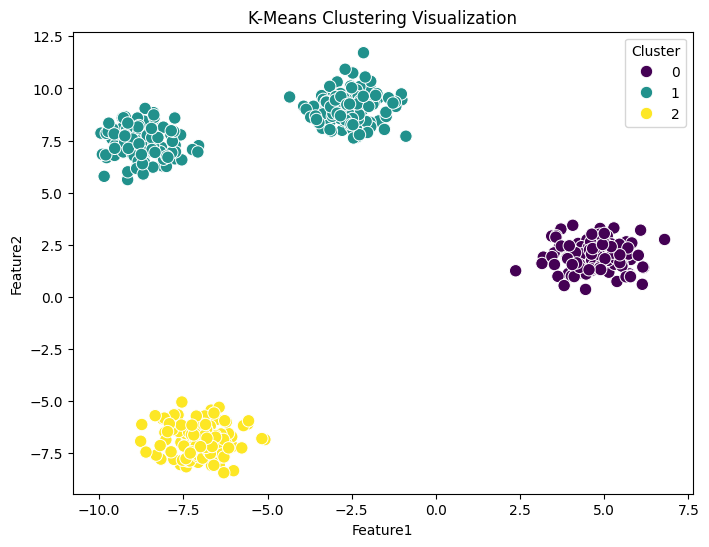

In [20]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,x="Feature1",y="Feature2",hue="Cluster",palette="viridis",s=80)

plt.title("K-Means Clustering Visualization")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")

plt.show()

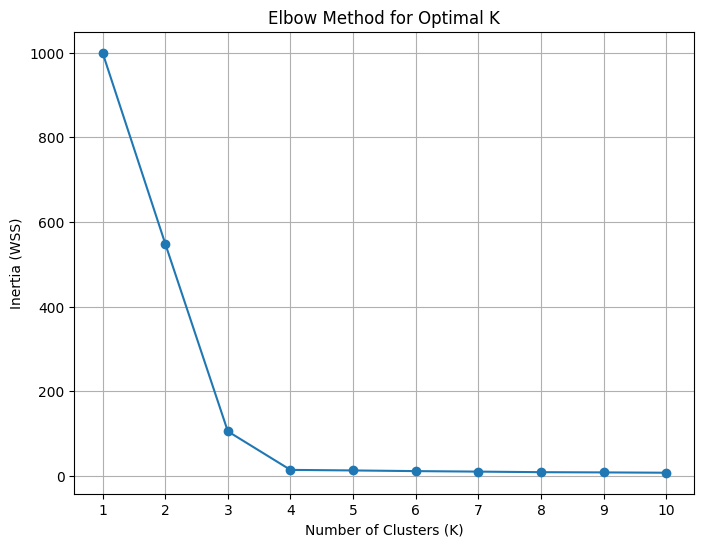

From the Elbow graph, the optimal value of K appears to be 4.


In [21]:
wss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='-')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()
print("From the Elbow graph, the optimal value of K appears to be 4.")

In [22]:
final_kmeans = KMeans(n_clusters=4, random_state=42)

final_clusters = final_kmeans.fit_predict(X_scaled)

df["Final_Cluster"] = final_clusters

print("Number of Data Points in Each Cluster:")
print(df["Final_Cluster"].value_counts().sort_index())

Number of Data Points in Each Cluster:
Final_Cluster
0    125
1    125
2    125
3    125
Name: count, dtype: int64


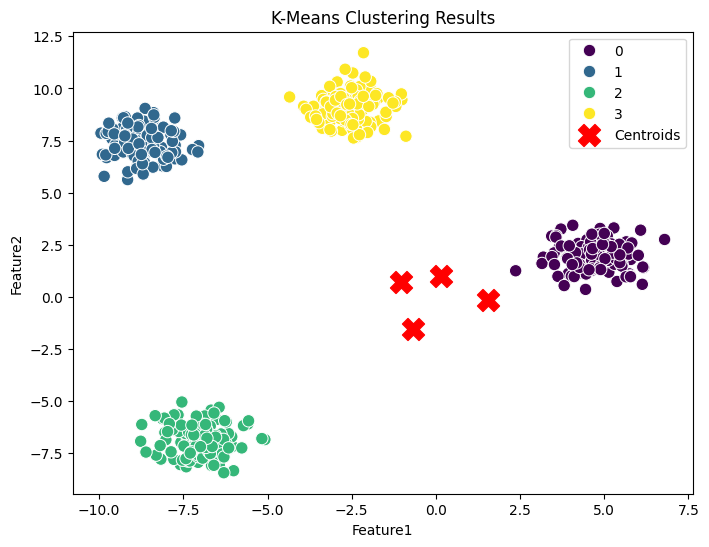

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,x="Feature1",y="Feature2",hue="Final_Cluster",palette="viridis",s=80)

centroids = final_kmeans.cluster_centers_

plt.scatter(centroids[:, 0],centroids[:, 1],c="red",s=250,marker="X",label="Centroids")
plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()

plt.show()

In [24]:
df = sns.load_dataset("iris")

X = df.select_dtypes(include=["float64", "int64"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Number of Data Points in Each Cluster:")
print(df["Cluster"].value_counts())
print("\nUpdated DataFrame:")
print(df.head(10))

Number of Data Points in Each Cluster:
Cluster
0    96
1    33
2    21
Name: count, dtype: int64

Updated DataFrame:
   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        2
2           4.7          3.2           1.3          0.2  setosa        2
3           4.6          3.1           1.5          0.2  setosa        2
4           5.0          3.6           1.4          0.2  setosa        1
5           5.4          3.9           1.7          0.4  setosa        1
6           4.6          3.4           1.4          0.3  setosa        1
7           5.0          3.4           1.5          0.2  setosa        1
8           4.4          2.9           1.4          0.2  setosa        2
9           4.9          3.1           1.5          0.1  setosa        2


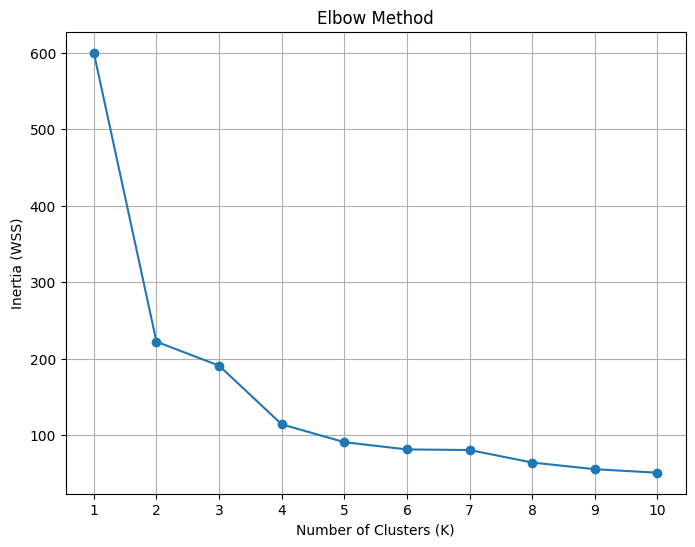

Cluster Sizes:
Final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


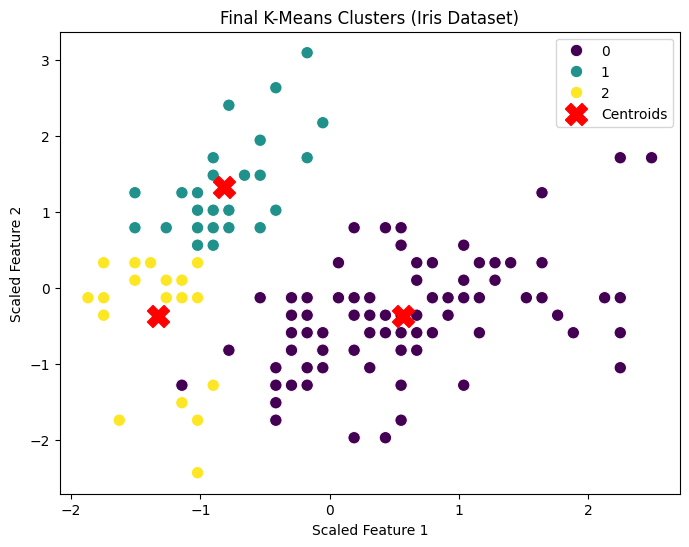

In [25]:
wss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()
optimal_k = 3

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)

df["Final_Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Cluster Sizes:")
print(df["Final_Cluster"].value_counts().sort_index())

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X_scaled[:, 0],y=X_scaled[:, 1],hue=df["Final_Cluster"],palette="viridis",s=80)
centroids = final_kmeans.cluster_centers_

plt.scatter(centroids[:, 0],centroids[:, 1],c="red",marker="X",s=250,label="Centroids")

plt.title("Final K-Means Clusters (Iris Dataset)")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend()

plt.show()

First 5 Rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape:
(200, 5)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summa

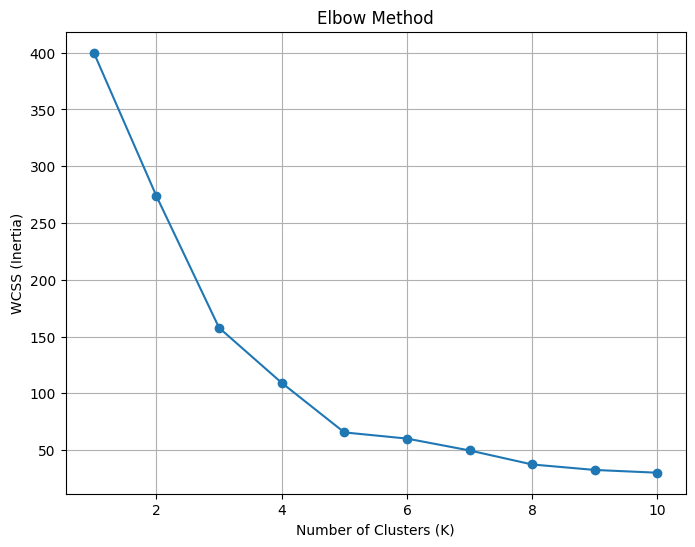


Cluster Sizes:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


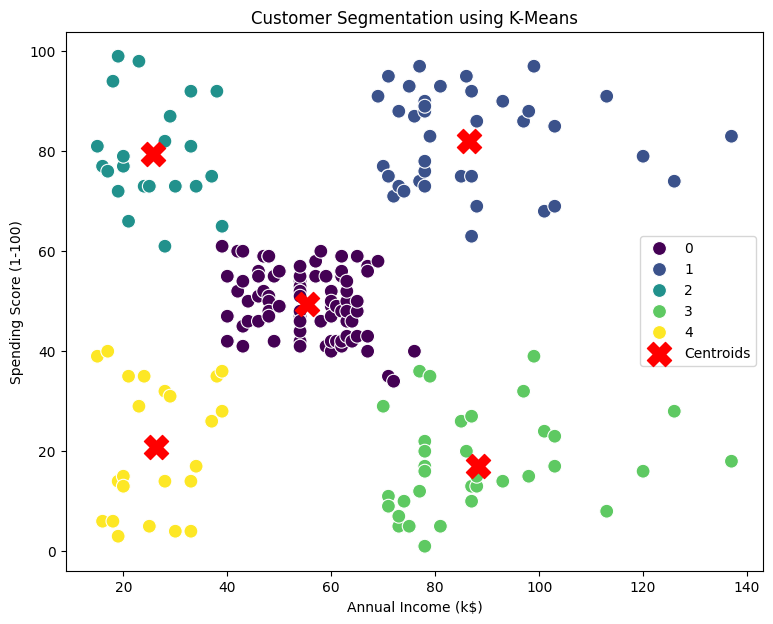

In [26]:
df = pd.read_csv("Mall_Customers.csv")

print("First 5 Rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nInformation:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()


optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Sizes:")
print(df["Cluster"].value_counts())
plt.figure(figsize=(9,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=300,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()